<a href="https://colab.research.google.com/github/evellynjardini/Data-Analytics---Grupo-24/blob/main/Tech_Challenge_Grupo_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1 - Importando e tratando as bases de dados da Olist

In [ ]:
import pandas as pd

# 1.Importando as bases em CSV

customers = pd.read_csv("/content/olist_customers_dataset.csv", sep=",", encoding='utf-8' )
geolocation = pd.read_csv("/content/olist_geolocation_dataset.csv", sep=",",encoding='utf-8' )
order_items = pd.read_csv("/content/olist_order_items_dataset.csv", sep=",", encoding='utf-8' )
order_payments = pd.read_csv("/content/olist_order_payments_dataset.csv", sep=",", encoding='utf-8' )
order_reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv", sep=",", encoding='utf-8' )
orders = pd.read_csv("/content/olist_orders_dataset.csv", sep=",", encoding='utf-8' )
products = pd.read_csv("/content/olist_products_dataset.csv", sep=",", encoding='utf-8' )
sellers = pd.read_csv("/content/olist_sellers_dataset.csv", sep=",", encoding='utf-8' )
category_name = pd.read_csv("/content/product_category_name_translation.csv", sep=",", encoding='utf-8' )

In [ ]:
customers.info() #Tabela sem valores nulos

In [ ]:
geolocation.info() #Tabela sem valores nulos

In [ ]:
order_items.info()#Tabela sem valores nulos

In [ ]:
order_payments.info() #Tabela sem valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_reviews.info() #Tabela tem valores nulos em campos como títulos de avaliação, avaliações, etc

In [ ]:
order_reviews['review_score'].value_counts(dropna=False) # Sem Valores nulos no review_score

In [ ]:
orders.info()

In [ ]:
orders['order_status'].value_counts(dropna=False)

In [ ]:
products['product_category_name'].value_counts(dropna=False)

In [ ]:
sellers.info()#Tabela sem valores nulos

In [ ]:
category_name.info() #Tabela sem valores nulos

In [ ]:
# Padronizando os Zip Code para inteiro, nas tabelas customers, sellers e geolocation

customers["customer_zip_code_prefix"] = (
    customers["customer_zip_code_prefix"]
    .astype(int)
)

sellers["seller_zip_code_prefix"] = (
    sellers["seller_zip_code_prefix"]
    .astype(int)
)

geolocation["geolocation_zip_code_prefix"] = (
    geolocation["geolocation_zip_code_prefix"]
    .astype(int)
)

In [ ]:
# Agrupando itens por order_id, pois este conjunto de dados inclui informações sobre os itens comprados em cada pedido, podendo haver duplicidade.

ordem_items_agrup = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        qtde_de_itens     = ("order_item_id", "count"),
        preco_total       =  ("price", "sum"), #considera somente o valor do produto, sem o frete
        freight_total     = ("freight_value", "sum"),
        sellers_distintos = ("seller_id", "nunique"),
        seller_id         = ("seller_id", "first"),
        product_id        = ("product_id", "first")
    )
)


In [ ]:
#ordem_items_agrup[ordem_items_agrup["sellers_distintos"] > 1].head()

In [ ]:
order_payments_agrup = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment     = ("payment_value", "sum"), #considera o valor do produto, com o frete -- CUSTO TOTAL
        payment_types     = ("payment_type", lambda x: ",".join(x.unique())),
        max_installments  = ("payment_installments", "max"),
        qtde_pagamentos    = ("payment_sequential", "count"),

    )
)


In [ ]:
# order_reviews["order_id"].value_counts()[lambda x: x > 1] # produtos com mais de 1 avaliação

In [ ]:
# order_reviews[order_reviews["order_id"] == "8e17072ec97ce29f0e1f111e598b0c85"]

In [ ]:
order_reviews["order_id"].duplicated().sum() # contando os duplicados

np.int64(551)

In [ ]:
reviews_recent = (
    order_reviews
    # criando coluna de prioridade: 0 = tem comentário, 1 = vazio
    .assign(
        prioridade=lambda x: (
            x["review_comment_message"].isna() &
            x["review_comment_title"].isna()
        ).astype(int)
    )
    # ordenando o primeiro quem tem dados (prioridade 0), depois mais recente
    .sort_values(
        ["order_id", "prioridade", "review_answer_timestamp"],
        ascending=[True, True, False]
    )
    # pegando o primeiro de cada grupo
    .drop_duplicates(subset="order_id", keep="first")

    # removendo a coluna auxiliar
    .drop(columns="prioridade")
)

In [ ]:
# reviews_recent[reviews_recent["order_id"] == "8e17072ec97ce29f0e1f111e598b0c85"]

In [ ]:
reviews_recent["order_id"].duplicated().sum()

In [ ]:
# reviews_recent[reviews_recent["order_id"] == "8e17072ec97ce29f0e1f111e598b0c85"]

In [ ]:
geolocation["geolocation_zip_code_prefix"].duplicated().sum()

In [ ]:
duplicadosgeo = geolocation[geolocation.duplicated(subset="geolocation_zip_code_prefix", keep=False)].sort_values("geolocation_zip_code_prefix")

print(f"Total de linhas duplicadas: {len(duplicadosgeo):,}")
print(f"zip cod prefix únicos: {duplicadosgeo['geolocation_zip_code_prefix'].nunique():,}")
duplicadosgeo.head(10)

Total de linhas duplicadas: 999,120
zip cod prefix únicos: 17,972


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
429,1001,-23.550498,-46.634338,sao paulo,SP
519,1001,-23.551337,-46.634027,sao paulo,SP
575,1001,-23.549779,-46.633957,são paulo,SP
596,1001,-23.550498,-46.634338,sao paulo,SP
206,1001,-23.550498,-46.634338,sao paulo,SP
583,1001,-23.551337,-46.634027,sao paulo,SP
608,1001,-23.550263,-46.634196,são paulo,SP
639,1001,-23.550498,-46.634338,sao paulo,SP
1384,1001,-23.549292,-46.633559,sao paulo,SP
1435,1001,-23.549292,-46.633559,sao paulo,SP


In [ ]:
# Mantendo apenas o PRIMEIRO geolocation_zip_code_prefix
geo_first = (
    geolocation
   .drop_duplicates(subset="geolocation_zip_code_prefix", keep="first")
)

In [ ]:
geo_first["geolocation_zip_code_prefix"].duplicated().sum()

In [ ]:
geo_first.info() # Conferindo zip_code_prefix Únicos

In [ ]:
# Consolidação da Base fato ORDERS com suas dimensões.

Base_Total_Olist = (
    orders
    .merge(customers,            on="customer_id",          how="left")
    .merge(ordem_items_agrup,    on="order_id",             how="left")
    .merge(products,             on="product_id",          how="left")
    .merge(category_name,        on="product_category_name",how="left")
    .merge(sellers,              on="seller_id",           how="left")
    .merge(order_payments_agrup, on="order_id",             how="left")
    .merge(reviews_recent,       on="order_id",             how="left")

 # geo do cliente
    .merge(
    geo_first
    .drop(columns=["geolocation_lat", "geolocation_lng"])
    .rename(columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_city":            "customer_city_geo",
        "geolocation_state":           "customer_state_geo",
    }),
    on="customer_zip_code_prefix",
    how="left",
)

# geo do vendedor
.merge(
    geo_first
    .drop(columns=["geolocation_lat", "geolocation_lng"])
    .rename(columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_city":            "seller_city_geo",
        "geolocation_state":           "seller_state_geo",
    }),
    on="seller_zip_code_prefix",
    how="left",
)
)

In [ ]:
import numpy as np

# Para customer_city
Base_Total_Olist['customer_city_oficial'] = np.where(
    Base_Total_Olist['customer_city_geo'].isna() & Base_Total_Olist['customer_city'].notna(),
    Base_Total_Olist['customer_city'],
    Base_Total_Olist['customer_city_geo']
)

# Para seller_city
Base_Total_Olist['seller_city_oficial'] = np.where(
    Base_Total_Olist['seller_city_geo'].isna() & Base_Total_Olist['seller_city'].notna(),
    Base_Total_Olist['seller_city'],
    Base_Total_Olist['seller_city_geo']
)

# Para customer_state
Base_Total_Olist['customer_state_oficial'] = np.where(
    Base_Total_Olist['customer_state_geo'].isna() & Base_Total_Olist['customer_state'].notna(),
    Base_Total_Olist['customer_state'],
    Base_Total_Olist['customer_state_geo']
)

# Para seller_state
Base_Total_Olist['seller_state_oficial'] = np.where(
    Base_Total_Olist['seller_state_geo'].isna() & Base_Total_Olist['seller_state'].notna(),
    Base_Total_Olist['seller_state'],
    Base_Total_Olist['seller_state_geo']
)

In [ ]:
Base_Total_Olist.head()

In [ ]:
Base_Total_Olist.shape

(99441, 48)

In [ ]:
todas_as_colunas = list(Base_Total_Olist.columns) #verificando o nome das colunas
todas_as_colunas

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'qtde_de_itens',
 'preco_total',
 'freight_total',
 'sellers_distintos',
 'seller_id',
 'product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'total_payment',
 'payment_types',
 'max_installments',
 'qtde_pagamentos',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'customer_city_geo',
 'customer_state_geo',
 'seller_city_geo',
 'seller_state_geo',
 'customer_city_oficial',
 

In [ ]:
#Ordenando e selecionando as variáveis que quero na base consolidada.

Base_Total_Olist = Base_Total_Olist[[

 'order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city_oficial',
 'customer_state_oficial',
 'qtde_de_itens',
 'preco_total',
 'freight_total',
 'sellers_distintos',
 'seller_id',
 'seller_zip_code_prefix',
 'seller_city_oficial',
 'seller_state_oficial',
 'product_id',
 'product_category_name',
 #'product_name_lenght',
 #'product_description_lenght',
 #'product_photos_qty',
 #'product_weight_g',
 #'product_length_cm',
 #'product_height_cm',
 #'product_width_cm',
 #'product_category_name_english',
 #'seller_city',
 #'seller_state',
 'total_payment',
 'payment_types',
 'max_installments',
 'qtde_pagamentos',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp'
 #'customer_city_geo',
 #'customer_state_geo',
 #'seller_city_geo',
 #'seller_state_geo',


]]


In [ ]:
# Convertendo as variáveis para formato de Data
colunas_de_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_answer_timestamp'
]

for coluna in colunas_de_data:
    Base_Total_Olist[coluna] = pd.to_datetime(Base_Total_Olist[coluna])

In [ ]:
Base_Total_Olist.shape

(99441, 32)

In [ ]:
Base_Total_Olist.info()

### 2 - Análises

In [ ]:
Base_Total_Olist['order_purchase_timestamp'].dt.to_period('M').drop_duplicates().sort_values().reset_index(drop=True)

,order_purchase_timestamp
0,2016-09
1,2016-10
2,2016-12
3,2017-01
4,2017-02
5,2017-03
6,2017-04
7,2017-05
8,2017-06
9,2017-07


In [ ]:
Base_Total_Olist['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

,count
order_purchase_timestamp,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


In [ ]:
# Analisando a receita por ano

Base_Total_Olist['ano_compra'] = Base_Total_Olist['order_purchase_timestamp'].dt.year #Criando uma coluna de Ano de Compra

Base_Faturamento = Base_Total_Olist[Base_Total_Olist['order_status'] == 'delivered']


In [ ]:
receita_por_ano = Base_Faturamento.groupby('ano_compra')['preco_total'].sum().reset_index() #tabela que sumariza a receita por ano


In [ ]:
def formata_moeda_br(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [ ]:
receita_por_ano["preco_total"].apply(formata_moeda_br)

,preco_total
0,"R$ 40.470,98"
1,"R$ 5.962.902,01"
2,"R$ 7.218.125,12"


In [ ]:
receita_por_ano

,ano_compra,preco_total
0,2016,40470.98
1,2017,5962902.01
2,2018,7218125.12


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Receita (R$ Milhões)')

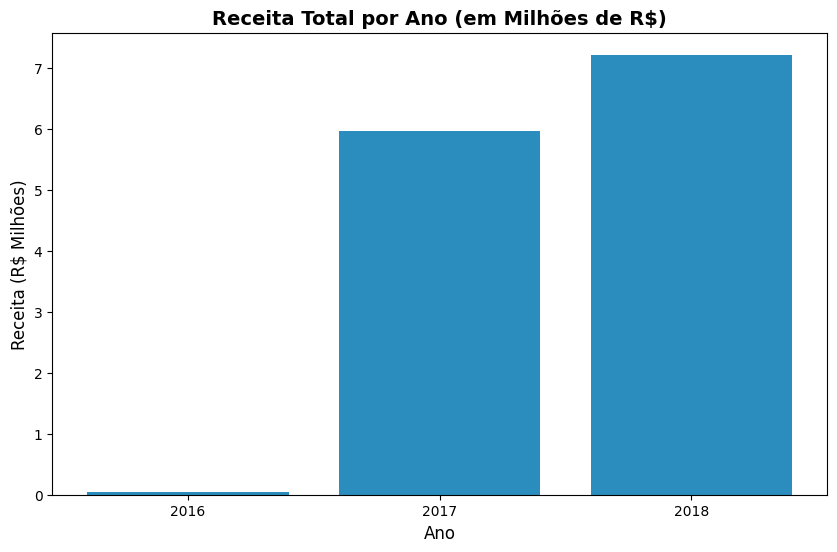

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(receita_por_ano['ano_compra'].astype(str), receita_por_ano['preco_total']/ 1000000, color='#2b8cbe')
plt.title('Receita Total por Ano (em Milhões de R$)', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Receita (R$ Milhões)', fontsize=12)

In [ ]:
Base_Faturamento['ano_mes'] = Base_Faturamento['order_purchase_timestamp'].dt.to_period('M')

/tmp/ipykernel_1552/1738675709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Base_Faturamento['ano_mes'] = Base_Faturamento['order_purchase_timestamp'].dt.to_period('M')


In [2]:
receita_por_mes = Base_Faturamento.groupby('ano_mes')['preco_total'].sum().reset_index()

In [ ]:
#media_por_mes = receita_por_mes['preco_total'].mean()

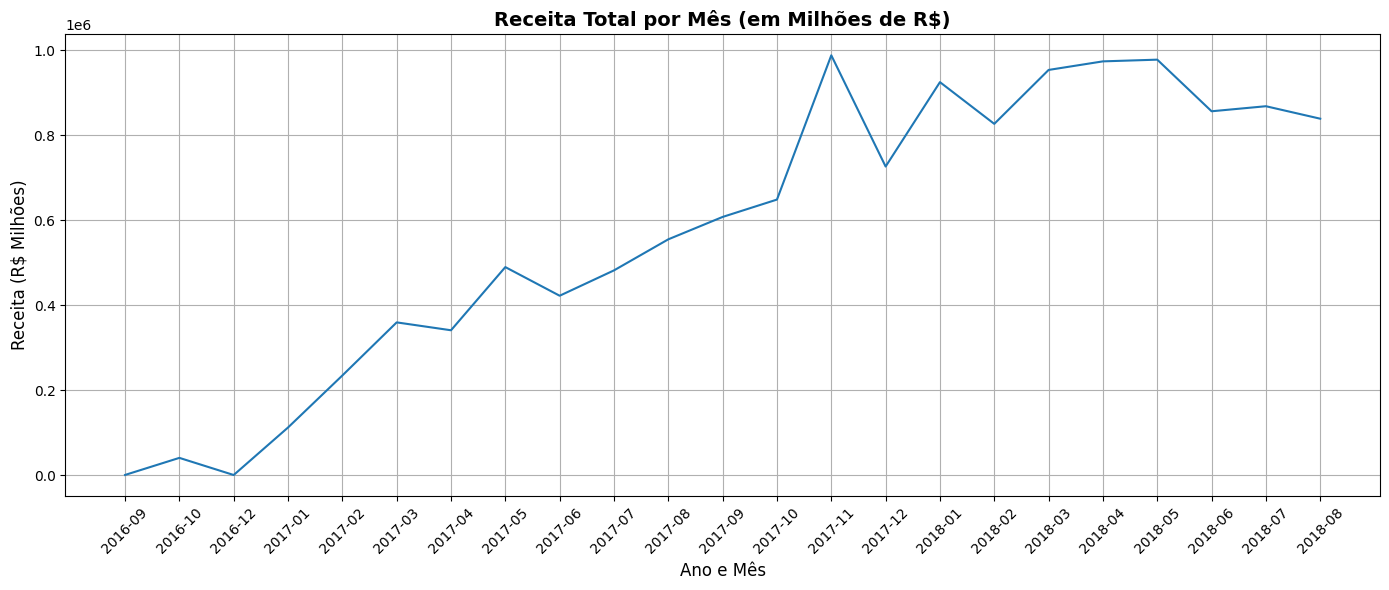

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(receita_por_mes['ano_mes'].astype(str), receita_por_mes['preco_total'] )
plt.title('Receita Total por Mês (em Milhões de R$)', fontsize=14, fontweight='bold')
plt.xlabel('Ano e Mês', fontsize=12)
plt.ylabel('Receita (R$ Milhões)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

###TESTES

In [ ]:
from google.colab import files

Base_Total_Olist.to_excel('Base_Total_Olist_Final.xlsx', index=False)

files.download('Base_Total_Olist_Final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>